# Final Project CS1460: BERT for Natural Question answering
Edouard Clocheret, Fall 2024

## Importing libraries

In [2]:
import importlib
import random
import json

import torch
import torch.nn as nn
import transformers
from transformers import DistilBertModel
from transformers import AutoTokenizer

import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support


packages = ["json", "torch", "transformers", "tqdm", "matplotlib", "sklearn"]

for package in packages:
    module = importlib.import_module(package)
    print(f"{package} version: {module.__version__}")

json version: 2.0.9
torch version: 2.6.0.dev20241112
transformers version: 4.47.0
tqdm version: 4.67.1
matplotlib version: 3.9.3
sklearn version: 1.6.0


In [3]:
# Checking if I can use pytorch with my local GPU (MPS)

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    print(OK, "MPS is available:", torch.backends.mps.is_available())
    print(OK, "MPS is built:", torch.backends.mps.is_built())
    print("device = mps (GPU)")
    device = "mps"
else :
    print(FAIL, "MPS support is not available in this version of PyTorch.")
    print("device = cpu")
    device = "cpu"

[ OK ] MPS is available: True
[ OK ] MPS is built: True
device = mps (GPU)


## Importing data

In [4]:
dev_set_path = "./all_dev.json"
train_set_path = "./all_train.json"

with open(dev_set_path, 'r') as file:
    raw_dev_data = json.load(file)

with open(train_set_path, 'r') as file:
    raw_train_data = json.load(file)

print("Example of a data point:")
print(json.dumps(raw_dev_data[0], indent=4))

Example of a data point:
{
    "name": "Mandalay Bay",
    "id": "7811140318762480311",
    "questions": [
        {
            "input_text": "who is the owner of the mandalay bay in vegas"
        }
    ],
    "answers": [
        {
            "candidate_id": 0,
            "span_text": "MGM Resorts International",
            "span_start": 576,
            "span_end": 601,
            "input_text": "short"
        }
    ],
    "has_correct_context": true,
    "contexts": "Mandalay Bay Location Paradise , Nevada , U.S. Address 3950 South Las Vegas Boulevard Opening date March 2 , 1999 ; 18 years ago ( March 2 , 1999 ) Theme Tropical No. of rooms 3,309 Total gaming space 135,000 sq ft ( 12,500 m ) Permanent shows Michael Jackson : One Signature attractions Mandalay Bay Convention Center Mandalay Bay Events Center Shark Reef House of Blues Mandalay Beach Notable restaurants Aureole Alain Ducasse Rivea Charlie Palmer Steak Fleur by Hubert Keller Kumi Lupo Red Square RM Seafood Stripste

In [4]:
print(f"#{raw_dev_data[0]['answers'][0]['span_text']}#")

start = raw_dev_data[0]['answers'][0]['span_start']
end = raw_dev_data[0]['answers'][0]['span_end']

print(f"#{raw_dev_data[0]['contexts'][start:end]}#") 
print("Span counted in char")

#MGM Resorts International#
#MGM Resorts International#
Span counted in char


## Data preprocessing

**Tokenization and preprocessing**

"We tokenize every example in NQ using a 30,522 wordpiece vocabulary, then generate multiple instances per example by concatenating a “[CLS]” token, the tokenized question, a “[SEP]” token, tokens from the content of the document, and a final “[SEP]”token, limiting the total size of each instance to 512 tokens." Devlin et al. (2018) 

*t ∈ {0,1} is the annotated answer
type, corresponding to the labels “no-answer” and “short”.*



In [19]:


def tokenize_for_transormer(question: str, context:str, tokenizer : AutoTokenizer, 
                            start_char: int, end_char: int, output_type : str):
    """
    Outputs tokenized examples and labels
    example:
    "[CLS] question [SEP] context [SEP]"
    is the format :
    {
    'input_ids': tensor([[ 101, 2209, 2023, 2955, 102,  2325, 2032, 1996, 2927, 2226, 102, ...]]),
    'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..., 0, 0 , 0]]),
    'offset_mapping': [(0, 0), (0, 5), (6, 9), (10, 14), (15, 16), ..., (0,0)]
    }
    labels [start_token, end_token, int(output_type)]
    """
    
    tokenized_input = tokenizer(question, context, 
                                 is_split_into_words=False, 
                                 return_offsets_mapping=True, 
                                 add_special_tokens=True,
                                 padding='max_length',
                                 max_length=512,
                                 truncation=True)
    

    # Creating labels : spans in terms of tokens
    offset_mapping = tokenized_input['offset_mapping']
    attention_mask = tokenized_input['attention_mask']
    context_start_idx = len(tokenizer.tokenize(question)) +2 # two for CLS and SEP
    context_end_idx = sum(attention_mask)-1 # one for SEP

    if start_char == -1 or end_char == -1 :
        start_token =0
        end_token =0
        assert output_type == 'no_answer'
    else :
        start_token = None
        end_token = None

        for i, (start, end) in enumerate(offset_mapping):
            if i >= context_start_idx and i < context_end_idx:
                if start_token is None and start <= start_char <= end:
                    start_token = i
                if end_token is None and start <= end_char <= end:
                    end_token = i
        
        if start_token is None or end_token is None :
            # The tokenizer might have cut the context
            start_token =0
            end_token =0
            output_type == 'no_answer'
    
    token_labels = [start_token, end_token, int(output_type == 'short')]

    return tokenized_input, token_labels



question = "what is the time ?"
context = "it is 8:30 pm"

start_char = 6
end_char = 13

output_type = 'short'

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tokenized_input, token_labels = tokenize_for_transormer(question, context, tokenizer, 
                            start_char, end_char, output_type)

# print(tokenized_result['input_ids'])
tokens_text = tokenizer.convert_ids_to_tokens(tokenized_input['input_ids'])
print(f"Tokens: {tokens_text}")
print(f"Span mapping: {tokenized_input['offset_mapping']}")
print(f"Labels: {token_labels}")


Tokens: ['[CLS]', 'what', 'is', 'the', 'time', '?', '[SEP]', 'it', 'is', '8', ':', '30', 'pm', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD

In [15]:
def get_example_X_y(example : int):
    """
    input :
    example = raw_dev_data[0]
    """

    question = example['questions'][0]['input_text']
    context = example['contexts']
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    output_type = example['answers'][0]['input_text']
    start_char = example['answers'][0]["span_start"]
    end_char = example['answers'][0]['span_end']

    tokenized_input, token_labels = tokenize_for_transormer(question, context, tokenizer, 
                            start_char, end_char, output_type)
    
    
    return tokenized_input, token_labels



tokenized_input, token_labels = get_example_X_y(raw_dev_data[0])
tokens_text = tokenizer.convert_ids_to_tokens(tokenized_input['input_ids'])
print(f"Tokens: {tokens_text}")
print(f"Span mapping: {tokenized_input['offset_mapping']}")
print(f"Labels: {token_labels}")

Tokens: ['[CLS]', 'who', 'is', 'the', 'owner', 'of', 'the', 'mandal', '##ay', 'bay', 'in', 'vegas', '[SEP]', 'mandal', '##ay', 'bay', 'location', 'paradise', ',', 'nevada', ',', 'u', '.', 's', '.', 'address', '395', '##0', 'south', 'las', 'vegas', 'boulevard', 'opening', 'date', 'march', '2', ',', '1999', ';', '18', 'years', 'ago', '(', 'march', '2', ',', '1999', ')', 'theme', 'tropical', 'no', '.', 'of', 'rooms', '3', ',', '309', 'total', 'gaming', 'space', '135', ',', '000', 'sq', 'ft', '(', '12', ',', '500', 'm', ')', 'permanent', 'shows', 'michael', 'jackson', ':', 'one', 'signature', 'attractions', 'mandal', '##ay', 'bay', 'convention', 'center', 'mandal', '##ay', 'bay', 'events', 'center', 'shark', 'reef', 'house', 'of', 'blues', 'mandal', '##ay', 'beach', 'notable', 'restaurants', 'au', '##re', '##ole', 'alain', 'duc', '##asse', 'ri', '##ve', '##a', 'charlie', 'palmer', 'steak', 'fl', '##eur', 'by', 'hubert', 'keller', 'ku', '##mi', 'lu', '##po', 'red', 'square', 'rm', 'seafood'

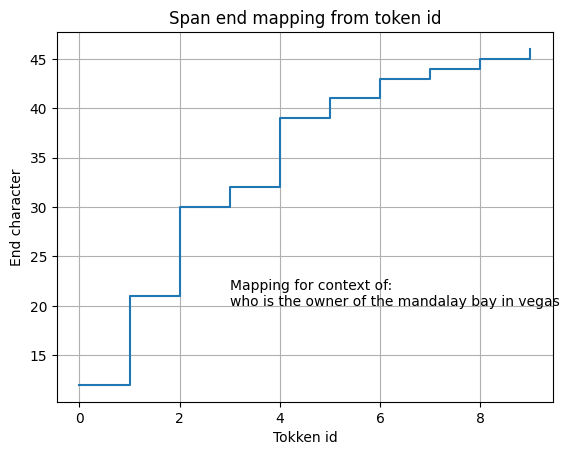

In [17]:
def map_tokens_to_chars(tokenized_intput, model_output):
    """
    This function is used to map the span outputted by the model (in tokens) back to the original span (counted in char)


    tokenized_intput is the input of the model
    modedel_output vector

    Returns:
    - char_start: The start character index of the answer in the context.
    - char_end: The end character index of the answer in the context.
    """
    start_token, end_token = model_output[0], model_output[1]
    offset_mapping = tokenized_intput['offset_mapping']
    
    assert start_token is not None and end_token is not None, "Start or End token not found"
    
    start_char = offset_mapping[start_token][0]
    end_char = offset_mapping[end_token][1]
    
    return start_char, end_char


example = raw_dev_data[0]
question = example['questions'][0]['input_text']
context = example['contexts']

end_chars = []
for i in range(15,25):
    model_output = [15, i, 1]
    start_char, end_char = map_tokens_to_chars(tokenized_input, model_output)

    end_chars.append(end_char)

plt.step(range(len(end_chars)), end_chars, where='post')
plt.title("Span end mapping from token id")
plt.xlabel("Tokken id")
plt.ylabel("End character")
plt.text(3,20,"Mapping for context of:\n"+ question)
plt.grid()
plt.show()


In [8]:

def preprocess_data(raw_data, tokenizer):
    preprocessed = []
    for example in raw_data:
        tokenized_input, token_labels = get_example_X_y(example)
        preprocessed.append({
            'input_ids': tokenized_input['input_ids'],
            'attention_mask': tokenized_input['attention_mask'],
            'labels': token_labels
        })
    return preprocessed

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")



# This allows to take subsets for dev
raw_train_data_sub = random.sample(raw_train_data, 27866)
raw_dev_data_sub = random.sample(raw_dev_data, 1743)
preprocessed_train_data = preprocess_data(raw_train_data_sub, tokenizer)
preprocessed_dev_data = preprocess_data(raw_dev_data_sub, tokenizer)


In [9]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, preprocessed_data):
        self.data = preprocessed_data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'input_ids': torch.tensor(item['input_ids']),
            'attention_mask': torch.tensor(item['attention_mask']),
            'labels': torch.tensor(item['labels'])
        }

train_dataset = CustomDataset(preprocessed_train_data)
dev_dataset = CustomDataset(preprocessed_dev_data)


BATCH_SIZE = 8

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_dataloader = torch.utils.data.DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)




for batch in dev_dataloader:
    print("Input IDs:", batch['input_ids'].shape)  # Shape should be (batch_size, max_length)
    print("Attention Mask:", batch['attention_mask'].shape)  # Shape should be (batch_size, max_length)
    print("Labels:", batch['labels'])  # Verify label structure
    break  # Only inspect the first batch


Input IDs: torch.Size([8, 512])
Attention Mask: torch.Size([8, 512])
Labels: tensor([[  0,   0,   0],
        [212, 225,   1],
        [ 51,  52,   1],
        [331, 331,   1],
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        [ 20,  25,   1]])


**Null downsampling**

"We downsample null instances by 50 times in order to obtain a training set
that has roughly as many null instances as non-null
instances" Alberti et al., 2019

In [10]:
for data, name in zip([raw_dev_data, raw_train_data], ["raw_dev_data", "raw_train_data"]):
    null_count =0
    short_count =0
    for i in range(len(data)):
        if data[i]['answers'][0]['input_text'] == 'no_answer':
            null_count+=1
        elif data[i]['answers'][0]['input_text'] == 'short':
            short_count +=1


    print("null_count",null_count)
    print("short_count", short_count)

    if null_count/(short_count+1) > 0.999 :
        print(OK, name, "correctly balanced")



null_count 872
short_count 871
[ OK ] raw_dev_data correctly balanced
null_count 13933
short_count 13933
[ OK ] raw_train_data correctly balanced


## Model

Based on Alberti, C., Lee, K. and Collins, M., 2019, A BERT Baseline for the Natural Questions. Google Research.


In [11]:


class CustomDistilBERTQA(nn.Module):
    def __init__(self, pretrained_model_name="distilbert-base-uncased"):
        super(CustomDistilBERTQA, self).__init__()
        
        self.distilbert = DistilBertModel.from_pretrained(pretrained_model_name)
        
        # Adding on top two output layers
        self.qa_outputs = nn.Linear(self.distilbert.config.hidden_size, 2)  
        # end and start token
        self.type_output = nn.Linear(self.distilbert.config.hidden_size, 2)  
        # binary: 'short' or 'no_answer'

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids=input_ids,attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        
        # Predict start and end logits
        logits = self.qa_outputs(sequence_output)  
        start_logits, end_logits = logits.split(1, dim=-1)
        start_logits = start_logits.squeeze(-1)
        end_logits = end_logits.squeeze(-1)

        # Predict answer type logits
        cls_token_representation = sequence_output[:, 0, :]  # First token => [CLS]
        type_logits = self.type_output(cls_token_representation)
        
        return start_logits, end_logits, type_logits
    
    def predict(self, input_ids, attention_mask):
        
        
        self.eval()
        with torch.no_grad():
            start_logits, end_logits, type_logits = self(input_ids, attention_mask)
            
            # Predictions from argmax of logits
            start_token = torch.argmax(start_logits, dim=-1)
            end_token = torch.argmax(end_logits, dim=-1)
            answer_type = torch.argmax(type_logits, dim=-1)
        
        return start_token, end_token, answer_type
    
    def compute_loss(self, start_logits, end_logits, type_logits, start_labels, end_labels, type_labels):
        
        start_loss = nn.CrossEntropyLoss()(start_logits, start_labels)
        end_loss = nn.CrossEntropyLoss()(end_logits, end_labels)

        type_labels_one_hot = torch.zeros_like(type_logits)  # To match the output shape
        type_labels_one_hot[torch.arange(type_labels.size(0)), type_labels] = 1  # One-hot encode the labels

        type_loss = nn.BCEWithLogitsLoss()(type_logits, type_labels_one_hot.float())

        total_loss = start_loss + end_loss + type_loss
        return total_loss

In [12]:

tokenizer = transformers.AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = CustomDistilBERTQA(pretrained_model_name="distilbert-base-uncased")
model.to(device)


CustomDistilBERTQA(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1

In [13]:
train_dataloader = train_dataloader
val_dataloader = dev_dataloader


In [ ]:
# Evaluation

def eval():
    model.eval()
    all_start_preds = []
    all_end_preds = []
    all_type_preds=[]
    all_start_labels = []
    all_end_labels = []
    all_type_labels = []

    with torch.no_grad():
        for batch in tqdm(dev_dataloader, desc="Evaluating on dev set"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            start_logits, end_logits, type_logits = model(input_ids=input_ids, attention_mask=attention_mask)

            start_preds = torch.argmax(start_logits, dim=-1)
            end_preds = torch.argmax(end_logits, dim=-1)
            type_preds = torch.argmax(type_logits, dim=-1)

            all_start_preds.extend(start_preds.cpu().numpy())
            all_end_preds.extend(end_preds.cpu().numpy())
            all_type_preds.extend(type_preds.cpu().numpy())

            all_start_labels.extend(labels[:, 0].cpu().numpy())
            all_end_labels.extend(labels[:, 1].cpu().numpy())
            all_type_labels.extend(labels[:, 2].cpu().numpy())


    precision_start, recall_start, f1_start, _ = precision_recall_fscore_support(all_start_labels, all_start_preds, average='macro', zero_division=0)
    precision_end, recall_end, f1_end, _ = precision_recall_fscore_support(all_end_labels, all_end_preds, average='macro', zero_division=0)
    precision_type, recall_type, f1_type, _ = precision_recall_fscore_support(all_type_labels, all_type_preds, average='macro', zero_division=0)

    precision = (precision_start + precision_end + precision_type) / 3
    recall = (recall_start + recall_end + recall_type) / 3
    f1 = (f1_start + f1_end + f1_type) / 3

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\n")



In [15]:


optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


# Training loop, with intermediary evaluations
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        start_logits, end_logits, type_logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        start_labels = labels[:, 0]  # Start positions
        end_labels = labels[:, 1]    # End positions
        type_labels = labels[:, 2]   # Answer types

        loss = model.compute_loss(start_logits, end_logits, type_logits, start_labels, end_labels, type_labels)
        total_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 

    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1}, Avg Loss: {avg_loss}")
    eval()

Epoch 1/3:   0%|          | 0/3484 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Epoch 1/3: 100%|██████████| 3484/3484 [18:28<00:00,  3.14it/s]


Epoch 1, Avg Loss: 3.518897154908435


Evaluating on dev set: 100%|██████████| 218/218 [00:20<00:00, 10.82it/s]


Precision: 0.5736
Recall: 0.5610
F1 Score: 0.5512




Epoch 2/3: 100%|██████████| 3484/3484 [18:55<00:00,  3.07it/s]


...

Precision: 0.6065
Recall: 0.5929
F1 Score: 0.5844




Epoch 3/3: 100%|██████████| 3484/3484 [19:00<00:00,  3.05it/s]


Epoch 3, Avg Loss: 1.4174012305903603


Evaluating on dev set: 100%|██████████| 218/218 [00:20<00:00, 10.48it/s]

Precision: 0.6101
Recall: 0.6060
F1 Score: 0.5934




In [16]:
### Example of predictions 

for batch in val_dataloader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)

    start_token, end_token, answer_type = model.predict(input_ids, attention_mask)


    for i in range(5):
        print(f"Predicted Start Token: {start_token[i].item()}")
        print(f"Predicted End Token: {end_token[i].item()}")
        print(f"Predicted Answer Type: {answer_type[i].item()}")
        print("___________")

    break

Predicted Start Token: 0
Predicted End Token: 0
Predicted Answer Type: 0
___________
Predicted Start Token: 212
Predicted End Token: 212
Predicted Answer Type: 1
___________
Predicted Start Token: 51
Predicted End Token: 54
Predicted Answer Type: 1
___________
Predicted Start Token: 0
Predicted End Token: 331
Predicted Answer Type: 1
___________
Predicted Start Token: 256
Predicted End Token: 256
Predicted Answer Type: 1
___________


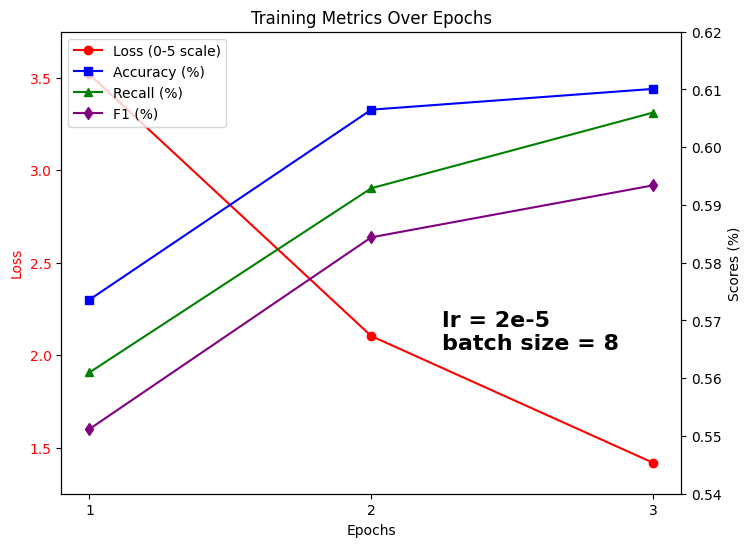

In [28]:
# With lr = 2e-5 and batch size = 8 

epochs = [1, 2, 3]
epoch_avg_losses = [3.518897154908435,2.103240690305273,1.4174012305903603]
accuracies = [0.5736,0.6065,0.6101]
recalls = [0.5610,0.5929,0.6060]
f1s = [0.5512,0.5844,0.5934]


fig, ax1 = plt.subplots(figsize=(8, 6))

# ax1 = loss
ax1.plot(epochs, epoch_avg_losses, 'o-', color='red', label='Loss (0-5 scale)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='red')
ax1.set_ylim(1.25, 3.75)
ax1.tick_params(axis='y', labelcolor='red')

# ax2 = other metrics 
ax2 = ax1.twinx()
ax2.plot(epochs, accuracies, 's-', color='blue', label='Accuracy (%)')
ax2.plot(epochs, recalls, '^-', color='green', label='Recall (%)')
ax2.plot(epochs, f1s, 'd-', color='purple', label='F1 (%)')
ax2.set_ylabel('Scores (%)', color='black')
ax2.set_ylim(0.54, 0.62)
ax2.tick_params(axis='y', labelcolor='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')


plt.text(2.25, 0.565, "lr = 2e-5\nbatch size = 8", fontsize=16, color="black", fontweight="bold")
plt.xticks([1, 2, 3])

plt.title('Training Metrics Over Epochs')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()




In [25]:
eval()

Evaluating on dev set: 100%|██████████| 218/218 [00:19<00:00, 11.22it/s]

Precision: 0.6101
Recall: 0.6060
F1 Score: 0.5934


